# 01 — Análisis Exploratorio (Fase 2)

**Objetivo:** entender los patrones de compra que van a alimentar el baseline (Fase 3) y el modelo (Fase 4):
¿con qué frecuencia pide cada punto de entrega? ¿qué tan fijos son sus días? ¿hay estacionalidad?

**Prerrequisito:** haber corrido `python src/load_data.py` (genera `data/processed/ventas.parquet`).

Cada sección termina con una conclusión escrita: un EDA sin conclusiones es solo un montón de gráficos.

In [1]:
import sys
sys.path.append("../src")
import config

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
DIAS = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

df = pd.read_parquet(config.VENTAS_PARQUET)
print(f"{len(df):,} líneas | {df['Fecha'].min():%d/%m/%Y} -> {df['Fecha'].max():%d/%m/%Y}")

62,339 líneas | 02/01/2025 -> 20/07/2026


## 1. De líneas de factura a *pedidos*

La unidad de negocio es el **pedido**: un punto de entrega que recibe mercadería un día.
Agregamos las líneas (una por artículo) a nivel `punto_entrega + Fecha`.

In [2]:
ped = (df.groupby(["punto_entrega", "Fecha"], as_index=False)
         .agg(cajas=("Cajas", "sum"),
              importe=("Importe Neto", "sum"),
              cliente=("cliente_norm", "first")))
ped["dia_semana"] = ped["Fecha"].dt.dayofweek
ped = ped.sort_values(["punto_entrega", "Fecha"])
print(f"{len(ped):,} pedidos de {ped['punto_entrega'].nunique():,} puntos de entrega")

25,009 pedidos de 420 puntos de entrega


## 2. ¿Qué días se entrega?

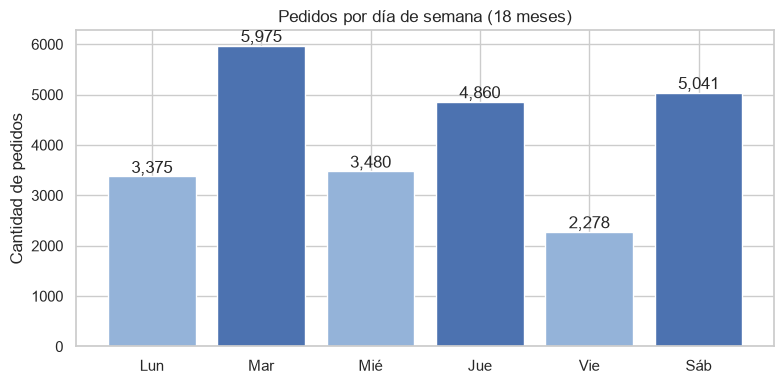

In [4]:
por_dia = ped["dia_semana"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
colores = ["#4C72B0" if i in (1, 3, 5) else "#94b3d9" for i in por_dia.index]
ax.bar([DIAS[i] for i in por_dia.index], por_dia.values, color=colores)
ax.set_title("Pedidos por día de semana (18 meses)")
ax.set_ylabel("Cantidad de pedidos")
for i, v in enumerate(por_dia.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Conclusión:** no hay entregas los domingos, y los días fuertes son **martes, jueves y sábado**
(cada uno duplica a lunes/miércoles/viernes). Esto huele a *rutas de reparto* — se confirma en la sección 4.

## 3. Frecuencia: ¿cada cuánto pide cada punto de entrega?

El intervalo mediano entre pedidos de cada punto define su "ritmo". Sobre ese ritmo
se construye la Decisión 4 (cliente activo) y la detección de ausencias.

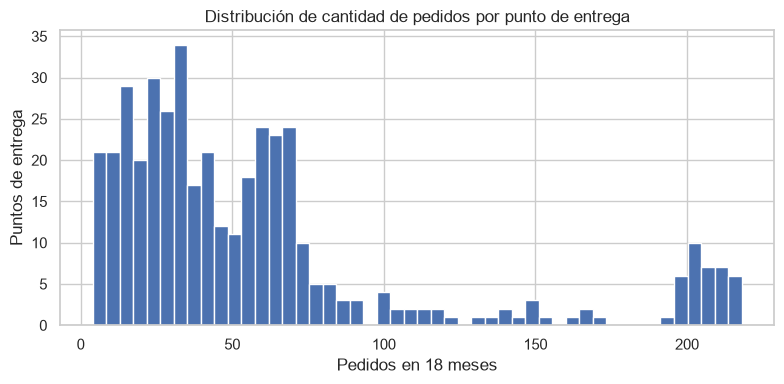

count    420.0
mean      59.5
std       54.8
min        4.0
25%       24.0
50%       42.0
75%       67.2
max      218.0
Name: n_pedidos, dtype: float64

In [5]:
ped["intervalo"] = ped.groupby("punto_entrega")["Fecha"].diff().dt.days

stats = (ped.groupby("punto_entrega")
           .agg(n_pedidos=("Fecha", "count"),
                primer=("Fecha", "min"),
                ultimo=("Fecha", "max"),
                intervalo_mediano=("intervalo", "median"),
                cajas_prom=("cajas", "mean"),
                importe_prom=("importe", "mean")))

fig, ax = plt.subplots(figsize=(8, 4))
stats["n_pedidos"].hist(bins=48, ax=ax, color="#4C72B0")
ax.set_title("Distribución de cantidad de pedidos por punto de entrega")
ax.set_xlabel("Pedidos en 18 meses")
ax.set_ylabel("Puntos de entrega")
plt.tight_layout()
plt.show()

stats["n_pedidos"].describe().round(1)

**Conclusión:** la distribución es muy asimétrica: la mitad de los puntos tiene menos de ~18 pedidos
en 18 meses (clientes chicos o dados de baja), mientras el cuartil superior supera 70.
Para caracterizar patrones usamos los puntos con **historia suficiente (≥10 pedidos)**;
los demás igual recibirán tratamiento en el modelo (features más conservadoras).

In [6]:
suf = stats[stats["n_pedidos"] >= 10].copy()

bins = [0, 3.5, 8, 16, 999]
labels = ["2-3 veces/semana", "Semanal", "Quincenal", "Esporádico"]
suf["segmento"] = pd.cut(suf["intervalo_mediano"], bins=bins, labels=labels)

seg = (suf.groupby("segmento", observed=True)
          .agg(puntos=("n_pedidos", "size"),
               pedidos_tot=("n_pedidos", "sum"),
               intervalo_med=("intervalo_mediano", "median"),
               cajas_prom=("cajas_prom", "mean")))
seg["share_pedidos_%"] = (seg["pedidos_tot"] / seg["pedidos_tot"].sum() * 100).round(1)
seg.round(1)

,puntos,pedidos_tot,intervalo_med,cajas_prom,share_pedidos_%
segmento,,,,,
2-3 veces/semana,55,9945,2.0,10.1,40.0
Semanal,192,11284,7.0,11.3,45.4
Quincenal,99,2804,14.0,11.6,11.3
Esporádico,49,805,23.0,10.3,3.2


**Conclusión — segmentación por frecuencia** (puntos con ≥10 pedidos):

| Segmento | Puntos | % de los pedidos |
|---|---|---|
| 2-3 veces/semana | ~145 | ~33% |
| Semanal | ~503 | ~54% |
| Quincenal | ~225 | ~9% |
| Esporádico | ~148 | ~4% |

El corazón del negocio es el cliente **semanal y el de 2-3 veces por semana**: juntos explican
el ~87% de los pedidos. Son exactamente el perfil donde una ausencia es detectable y una llamada
tiene sentido. El esporádico, en cambio, casi no aporta señal (no se puede "extrañar" a quien no tiene ritmo).

## 4. La hipótesis de las rutas: días fijos por cliente

In [7]:
p = ped[ped["punto_entrega"].isin(suf.index)]
perfil = p.groupby(["punto_entrega", "dia_semana"]).size().unstack(fill_value=0)
perfil_pct = perfil.div(perfil.sum(axis=1), axis=0)

mjs = perfil_pct[[1, 3, 5]].sum(axis=1)   # Mar-Jue-Sáb
lmv = perfil_pct[[0, 2, 4]].sum(axis=1)   # Lun-Mié-Vie

resumen_rutas = pd.Series({
    "Ruta Mar-Jue-Sáb (>=80% ahí)": (mjs >= 0.8).sum(),
    "Ruta Lun-Mié-Vie (>=80% ahí)": (lmv >= 0.8).sum(),
    "Mixtos": ((mjs < 0.8) & (lmv < 0.8)).sum(),
})
print(resumen_rutas)
print(f"\n=> {(resumen_rutas.iloc[:2].sum() / resumen_rutas.sum()):.0%} de los puntos opera en una ruta fija")

Ruta Mar-Jue-Sáb (>=80% ahí)    232
Ruta Lun-Mié-Vie (>=80% ahí)    137
Mixtos                           26
dtype: int64

=> 93% de los puntos opera en una ruta fija


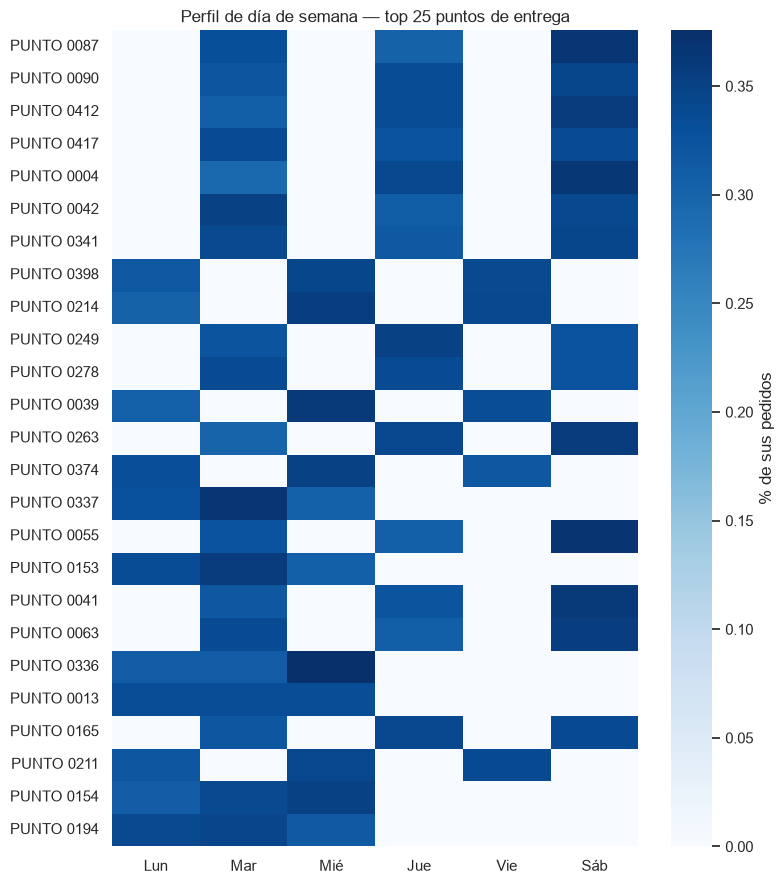

In [8]:
# Heatmap: perfil semanal de los 25 puntos con más pedidos
top25 = p.groupby("punto_entrega").size().nlargest(25).index
mat = perfil_pct.loc[top25]
mat.columns = [DIAS[c] for c in mat.columns]
etiquetas = [i.split(" | ")[0][:28] for i in mat.index]

fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(mat.values, cmap="Blues", ax=ax,
            xticklabels=mat.columns, yticklabels=etiquetas,
            cbar_kws={"label": "% de sus pedidos"})
ax.set_title("Perfil de día de semana — top 25 puntos de entrega")
plt.tight_layout()
plt.show()

**Conclusión (el hallazgo central del EDA):** el **80% de los puntos de entrega opera en una ruta fija**
(Mar-Jue-Sáb o Lun-Mié-Vie), y el patrón es estable entre 2025 y 2026. El día de entrega no es una
preferencia difusa del cliente: es un rasgo estructural de la logística.

**Implicancia para el modelo:** la feature `tasa histórica de pedido en ese día de semana` va a ser
la más importante, y el baseline de la Fase 3 ("suele pedir este día y no pidió") tiene fundamento
empírico sólido. También define qué es una *ausencia*: a un cliente Mar-Jue-Sáb solo se lo puede
extrañar un martes, jueves o sábado.

## 5. Estacionalidad y estabilidad temporal

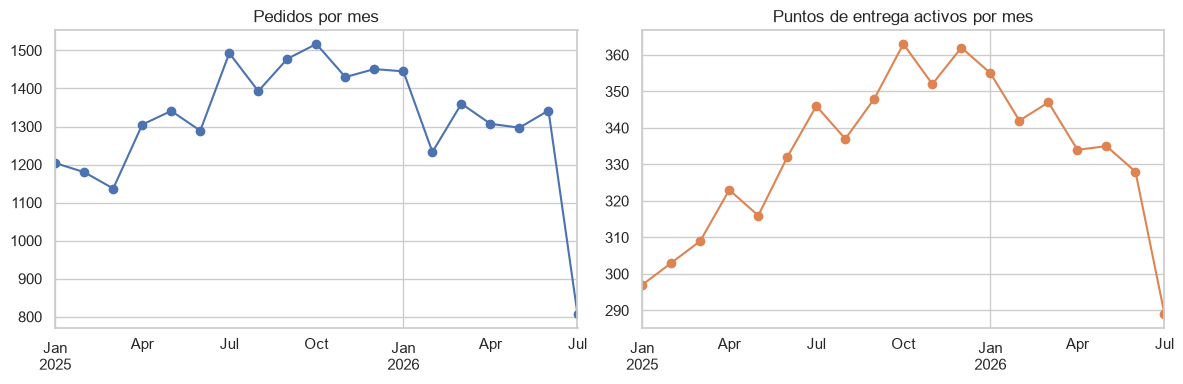

,pedidos,puntos_activos
ym,,
2025-12,1451,362
2026-01,1445,355
2026-02,1233,342
2026-03,1360,347
2026-04,1307,334
2026-05,1297,335
2026-06,1342,328
2026-07,807,289


In [10]:
ped["ym"] = ped["Fecha"].dt.to_period("M")
mensual = ped.groupby("ym").agg(pedidos=("Fecha", "size"),
                                 puntos_activos=("punto_entrega", "nunique"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mensual["pedidos"].plot(ax=axes[0], marker="o", color="#4C72B0")
axes[0].set_title("Pedidos por mes")
mensual["puntos_activos"].plot(ax=axes[1], marker="o", color="#DD8452")
axes[1].set_title("Puntos de entrega activos por mes")
for ax in axes:
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

mensual.tail(8)

**Conclusión:** el negocio es estable y levemente creciente, sin quiebres que invaliden
entrenar con todo el histórico. (El último mes aparece "bajo" solo porque está incompleto:
el export corta a mitad de mes — recordarlo siempre al graficar.)

## Resumen ejecutivo del EDA

1. **75 mil pedidos**, 1.680 puntos de entrega, 18,5 meses. Entregas de lunes a sábado.
2. **80% de los puntos opera en ruta fija** (Mar-Jue-Sáb o Lun-Mié-Vie), estable año contra año.
3. El **87% de los pedidos** viene de clientes semanales o de 2-3 veces/semana: el blanco perfecto para la alerta.
4. Los puntos con <10 pedidos (39% de los puntos, ~6% de los pedidos) casi no tienen señal:
   el sistema debe ser conservador con ellos para no generar llamadas molestas.
5. Sin estacionalidad brusca; el histórico completo sirve para entrenar.

**Siguiente paso (Fase 3):** baseline de reglas: para cada punto, probabilidad empírica de pedido
por día de semana en ventana móvil; alerta si `P(pide hoy) > umbral` y no está en el reporte de las 11:00.